<a href="https://colab.research.google.com/github/Maryjancy894/INTERNSHIP/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [4]:
df = pd.read_csv("ecommerce_products_killer.csv")

Step 3: View Dataset

First 5 Rows

In [5]:
print(df.head())

  product_id       product_name   brand     category subcategory  price  \
0    P100000          iPhone 13   Apple  Electronics  Smartphone  65372   
1    P100001         Zara Shirt    Zara      Fashion       Shirt   2616   
2    P100002  RayBan Sunglasses  RayBan  Accessories  Sunglasses   1305   
3    P100003      Puma Sneakers    Puma     Footwear    Sneakers   7471   
4    P100004       Nike T-shirt    Nike      Fashion     T-shirt   1305   

  currency  discount_percent  discounted_price  rating  reviews_count  \
0      INR                57          28109.96     3.7           3050   
1      INR                55           1177.20     4.1           4699   
2      INR                58            548.10     3.6           1700   
3      INR                60           2988.40     3.5            860   
4      INR                37            822.15     3.9            138   

   popularity_score   stock_status  date_added  \
0           11285.0  Limited Stock  2025-10-17   
1         

Last 5 Rows

In [6]:
print(df.tail())

     product_id    product_name brand     category subcategory  price  \
1995    P101995  H&M Sweatshirt   H&M      Fashion  Sweatshirt   3319   
1996    P101996     Puma Jacket  Puma      Fashion      Jacket   1436   
1997    P101997     Dell Laptop  Dell  Electronics      Laptop  63410   
1998    P101998  H&M Sweatshirt   H&M      Fashion  Sweatshirt    914   
1999    P101999   Puma Sneakers  Puma     Footwear    Sneakers   8941   

     currency  discount_percent  discounted_price  rating  reviews_count  \
1995      INR                62           1261.22     3.8           4201   
1996      INR                69            445.16     4.0           1580   
1997      INR                66          21559.40     4.0             75   
1998      INR                20            731.20     5.0           2863   
1999      INR                14           7689.26     4.4           4223   

      popularity_score   stock_status  date_added  \
1995           15963.8  Limited Stock  2024-09-17  

Step 4: Check Dataset Information

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_id        2000 non-null   object 
 1   product_name      2000 non-null   object 
 2   brand             2000 non-null   object 
 3   category          2000 non-null   object 
 4   subcategory       2000 non-null   object 
 5   price             2000 non-null   int64  
 6   currency          2000 non-null   object 
 7   discount_percent  2000 non-null   int64  
 8   discounted_price  2000 non-null   float64
 9   rating            2000 non-null   float64
 10  reviews_count     2000 non-null   int64  
 11  popularity_score  2000 non-null   float64
 12  stock_status      2000 non-null   object 
 13  date_added        2000 non-null   object 
 14  description       2000 non-null   object 
dtypes: float64(3), int64(3), object(9)
memory usage: 234.5+ KB
None


Step 5: Check Shape of Dataset

In [8]:
print("Rows and Columns :", df.shape)

Rows and Columns : (2000, 15)


Step 6: Check Column Names

In [10]:
print(df.columns)

Index(['product_id', 'product_name', 'brand', 'category', 'subcategory',
       'price', 'currency', 'discount_percent', 'discounted_price', 'rating',
       'reviews_count', 'popularity_score', 'stock_status', 'date_added',
       'description'],
      dtype='object')


Step 7: Check Missing Values

In [11]:
print(df.isnull().sum())

product_id          0
product_name        0
brand               0
category            0
subcategory         0
price               0
currency            0
discount_percent    0
discounted_price    0
rating              0
reviews_count       0
popularity_score    0
stock_status        0
date_added          0
description         0
dtype: int64


Step 8: Check Duplicate Rows

In [13]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


 DATA PREPROCESSING

Step 9: Remove Duplicate Rows

In [14]:
df = df.drop_duplicates()

Step 10: Fill Missing Numerical Values

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

Step 11: Fill Missing Categorical Values

In [17]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Step 12: Verify Missing Values Again

In [18]:
print(df.isnull().sum())

product_id          0
product_name        0
brand               0
category            0
subcategory         0
price               0
currency            0
discount_percent    0
discounted_price    0
rating              0
reviews_count       0
popularity_score    0
stock_status        0
date_added          0
description         0
dtype: int64


Step 13: Save Cleaned Dataset

In [19]:
df.to_csv("cleaned_ecommerce_dataset.csv", index=False)

DATA VISUALIZATION

Step 14: Histogram

Numerical data distribution

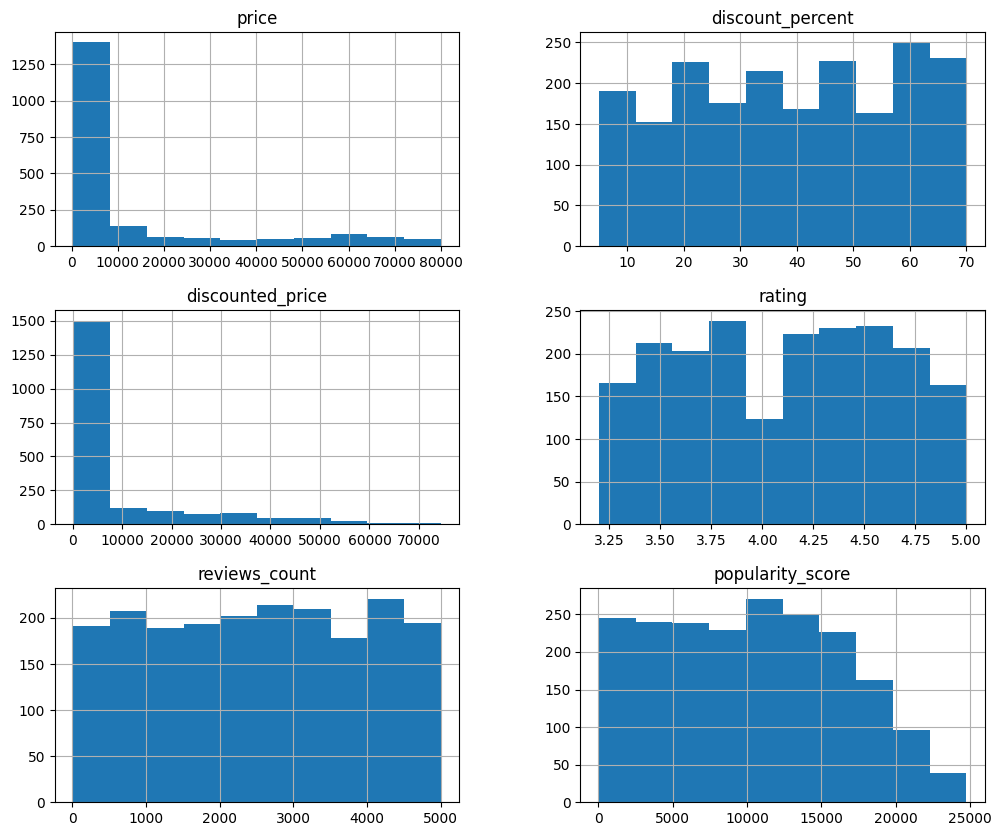

In [20]:
df.hist(figsize=(12,10))

plt.show()

Step 15: Correlation Heatmap

Columns relationship

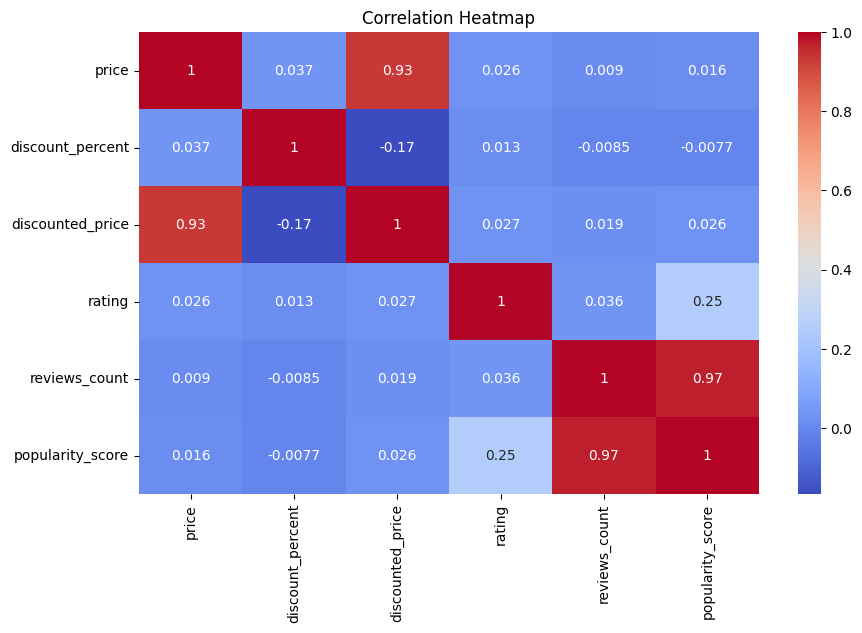

In [21]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Step 16: Countplot

Category-wise count check

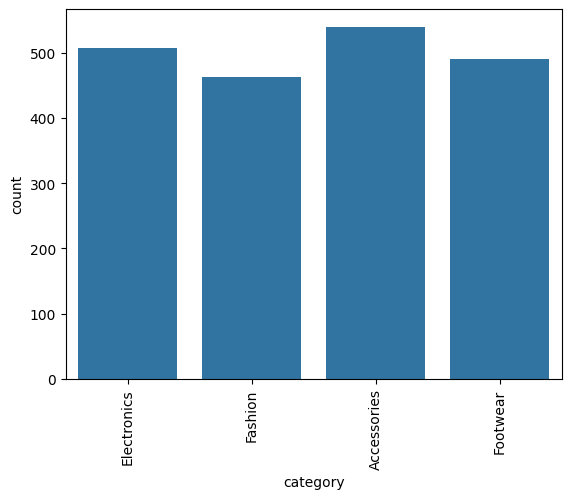

In [22]:
sns.countplot(x=df['category'])

plt.xticks(rotation=90)

plt.show()

Step 17: Boxplot

Outliers identify

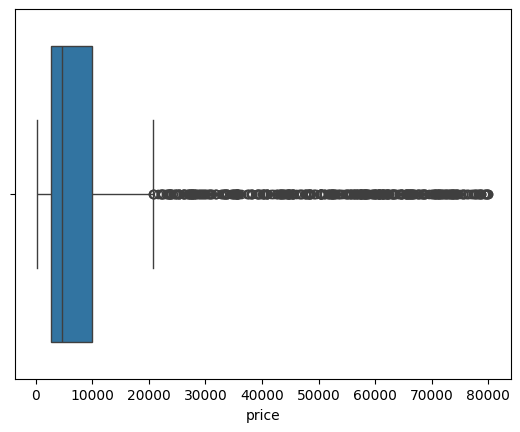

In [23]:
sns.boxplot(x=df['price'])

plt.show()

Step 18: Scatter Plot

Two numerical columns Relashionship


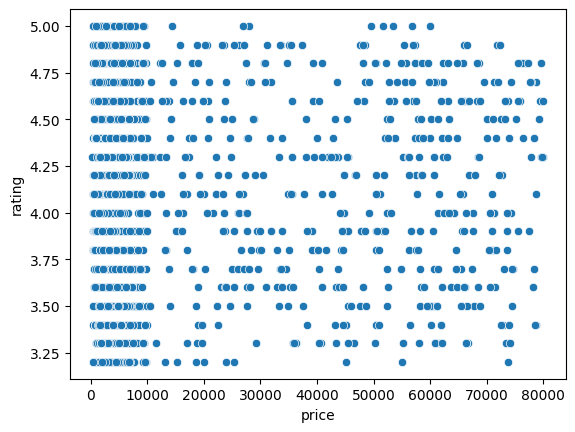

In [24]:
sns.scatterplot(x=df['price'],
                y=df['rating'])

plt.show()

Step 19: Pairplot

All numerical columns relationship.

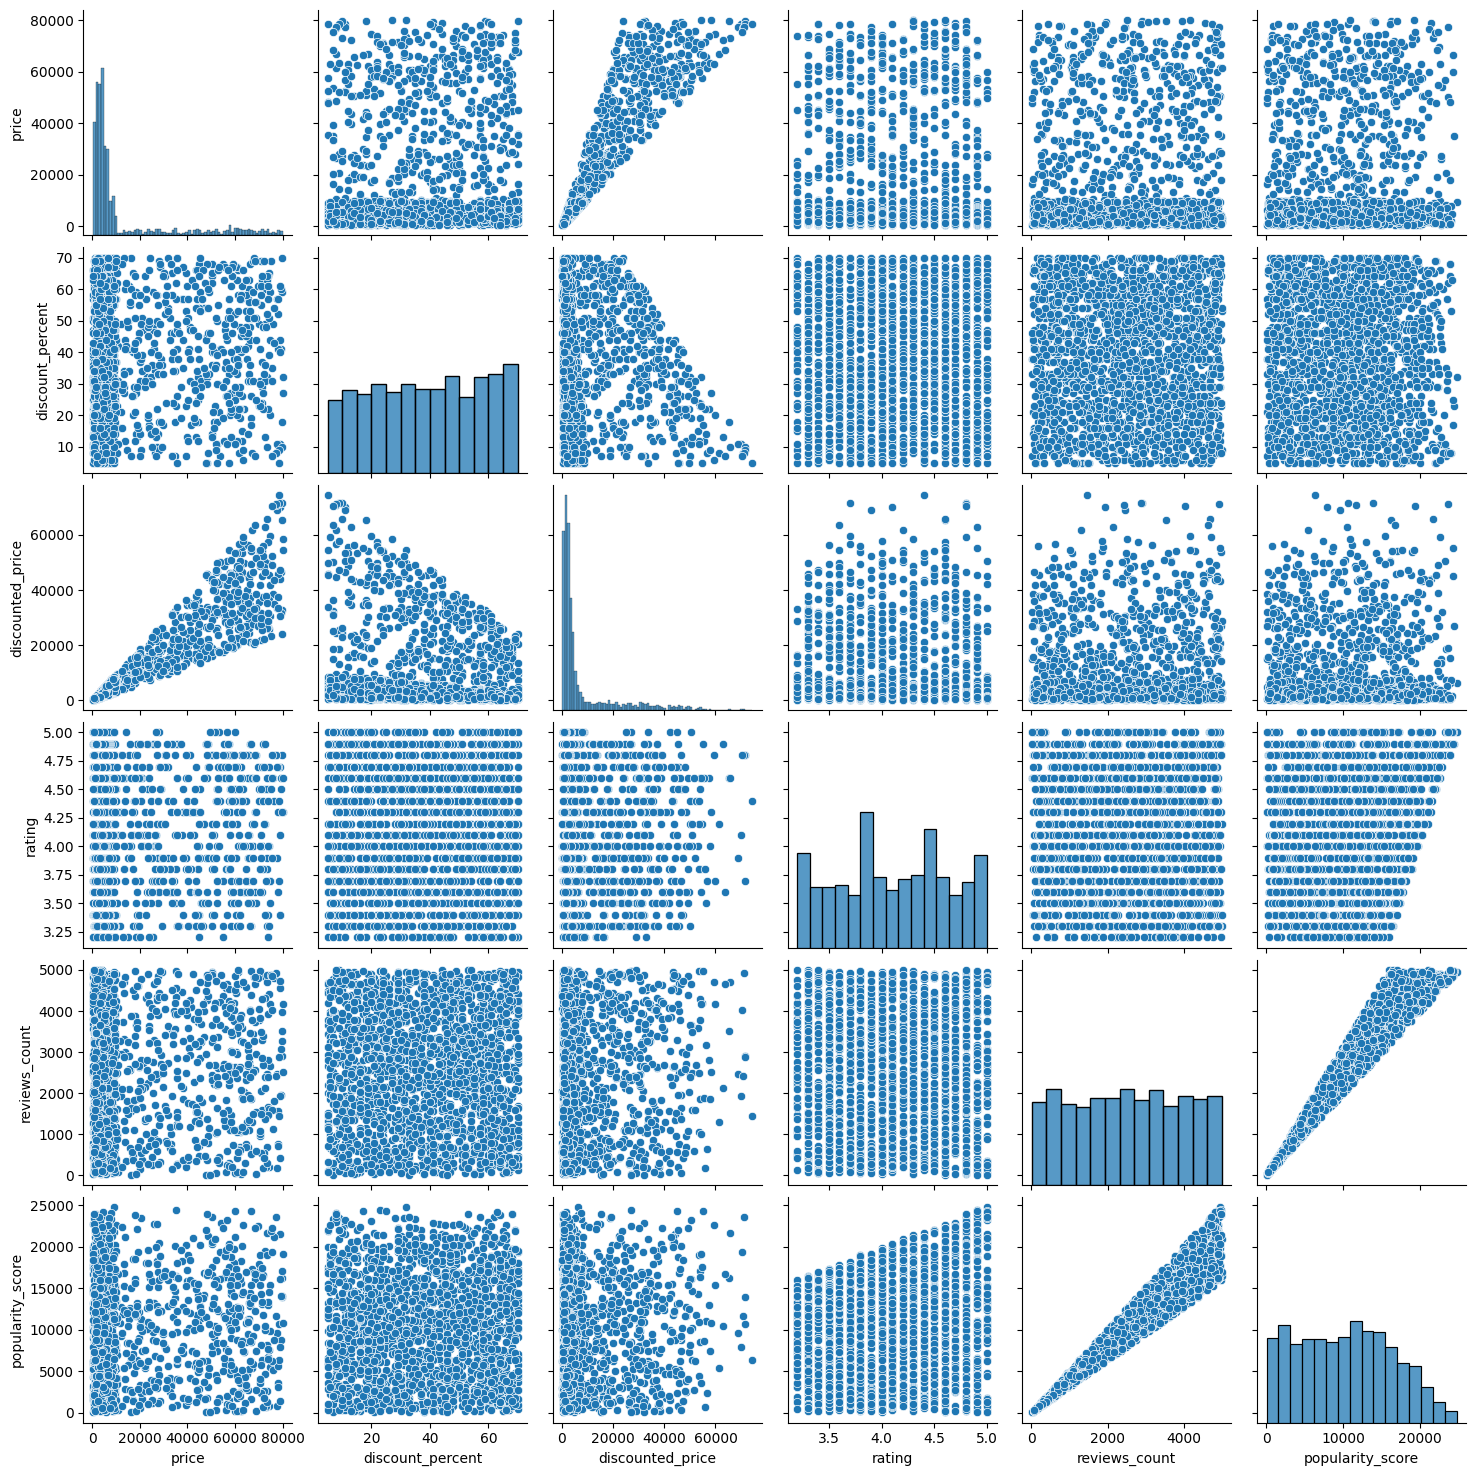

In [25]:
sns.pairplot(df)

plt.show()

Step 20: Final Dataset Check

In [26]:
print(df.head())

  product_id       product_name   brand     category subcategory  price  \
0    P100000          iPhone 13   Apple  Electronics  Smartphone  65372   
1    P100001         Zara Shirt    Zara      Fashion       Shirt   2616   
2    P100002  RayBan Sunglasses  RayBan  Accessories  Sunglasses   1305   
3    P100003      Puma Sneakers    Puma     Footwear    Sneakers   7471   
4    P100004       Nike T-shirt    Nike      Fashion     T-shirt   1305   

  currency  discount_percent  discounted_price  rating  reviews_count  \
0      INR                57          28109.96     3.7           3050   
1      INR                55           1177.20     4.1           4699   
2      INR                58            548.10     3.6           1700   
3      INR                60           2988.40     3.5            860   
4      INR                37            822.15     3.9            138   

   popularity_score   stock_status  date_added  \
0           11285.0  Limited Stock  2025-10-17   
1         